In [1]:
import pandas as pd

# Load the CSV file for Sudan
df = pd.read_csv("D:\Aman\KAIM-9\Week-0\Week0-climate-challange\climate-challenge-week0\data\sudan.csv")

# Add a Country column
df["Country"] = "Sudan"

# Convert YEAR and DOY to a proper datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month as a separate column
df["Month"] = df["Date"].dt.month

df.tail()

<>:4: SyntaxWarning: invalid escape sequence '\A'
<>:4: SyntaxWarning: invalid escape sequence '\A'
C:\Users\a00928253\AppData\Local\Temp\ipykernel_23848\2989818018.py:4: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv("D:\Aman\KAIM-9\Week-0\Week0-climate-challange\climate-challenge-week0\data\sudan.csv")


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,2026-03-27,3
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28,3
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29,3
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30,3
4107,2026,90,33.79,42.64,25.73,16.91,0.0,13.89,3.52,5.00,95.89,4.47,Sudan,2026-03-31,3


In [2]:
import numpy as np

# Replace all -999 with np.nan
df = df.replace(-999, np.nan)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop duplicates if any
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Number of duplicate rows: 0


In [3]:
# Run df.describe() on all numeric columns
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


In [4]:
# Check missing values
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

# Filter columns with >5% missing
high_missing = missing_summary[missing_summary['Missing %'] > 5]
print("Columns with >5% missing values:")
print(high_missing)

# Show all missing values
print("\nAll columns with missing values:")
print(missing_summary[missing_summary['Missing Count'] > 0])

Columns with >5% missing values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

All columns with missing values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [5]:
from scipy.stats import zscore

cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
print(outliers)

T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64


<Axes: xlabel='Date'>

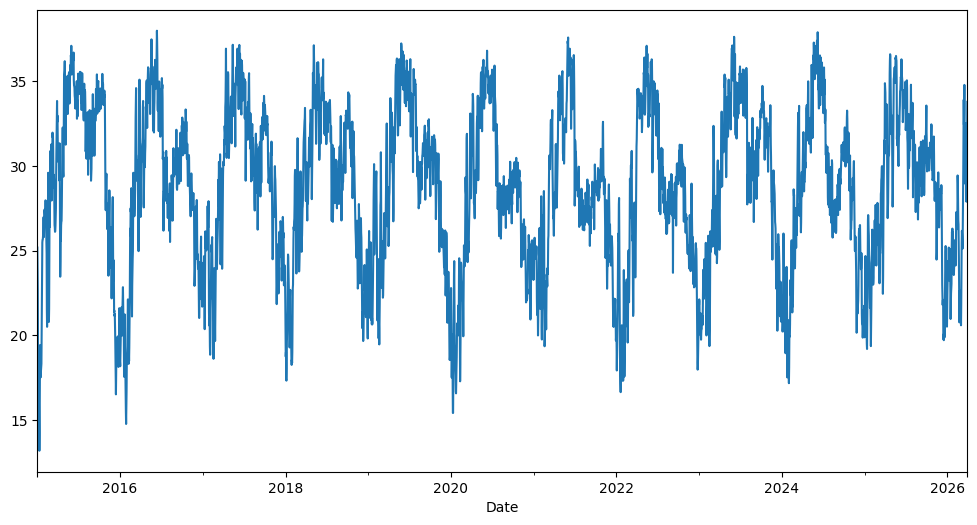

In [6]:
monthly_temp = df.groupby("Date")["T2M"].mean()

monthly_temp.plot(figsize=(12,6))

<Axes: xlabel='Month'>

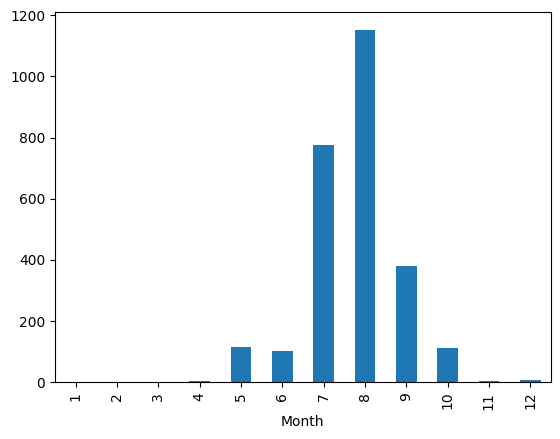

In [7]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")

<Axes: >

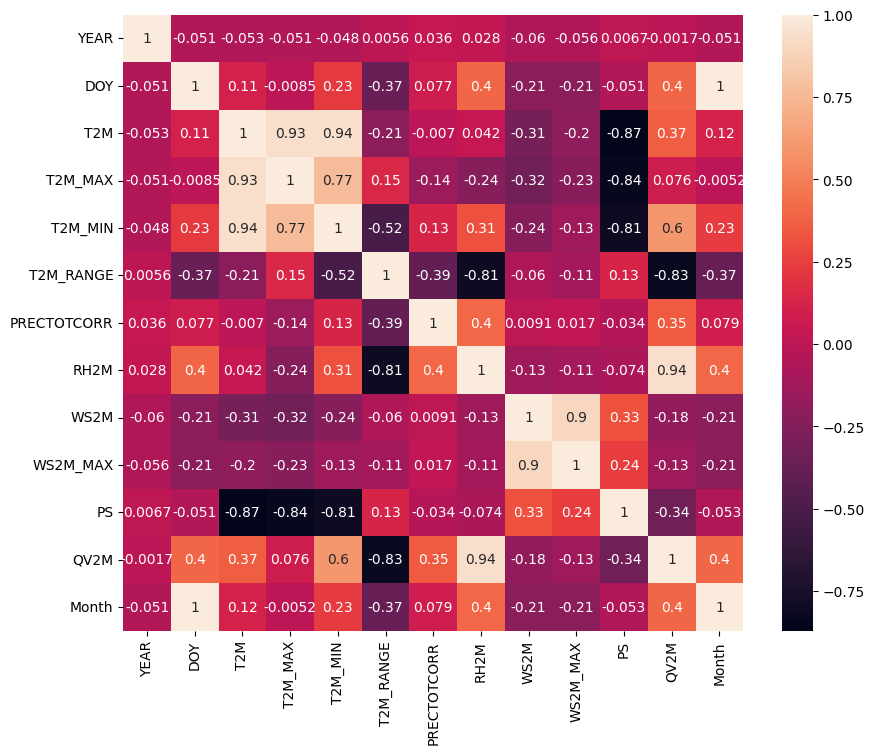

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='T2M', ylabel='RH2M'>

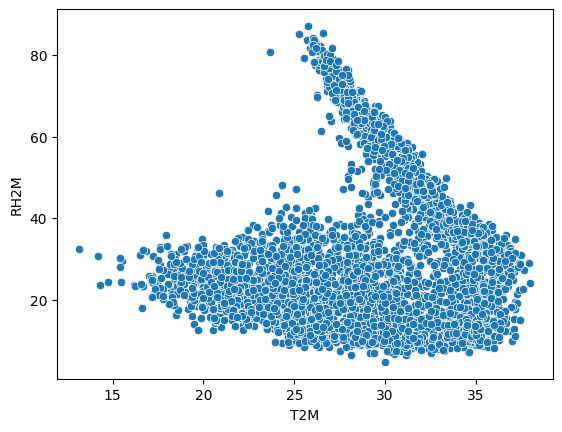

In [9]:
sns.scatterplot(data=df, x="T2M", y="RH2M")


<Axes: xlabel='T2M_RANGE', ylabel='WS2M'>

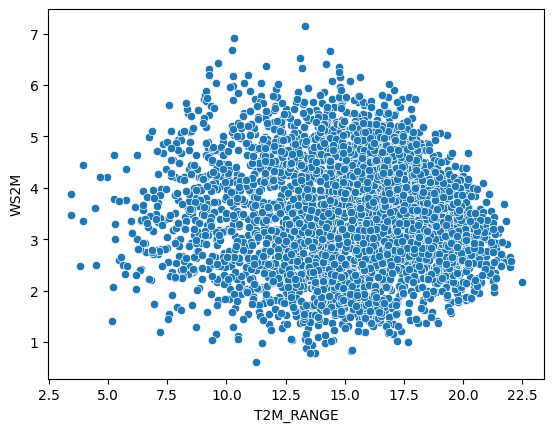

In [10]:
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")

<Axes: xlabel='PRECTOTCORR', ylabel='Count'>

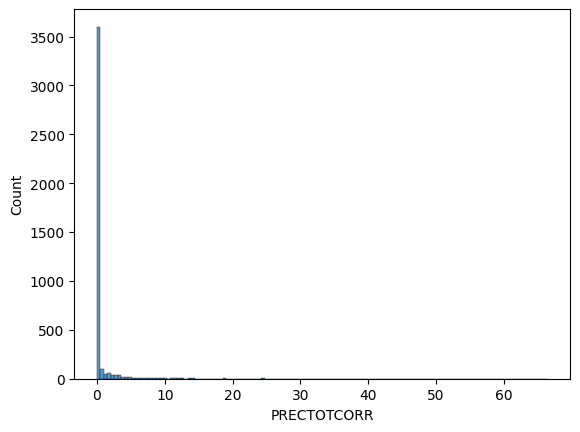

In [11]:
sns.histplot(df["PRECTOTCORR"])

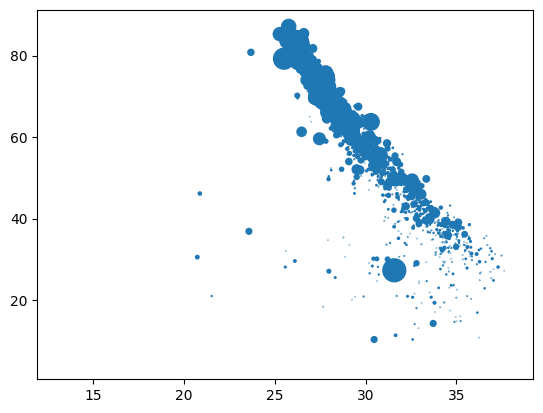

In [12]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*5
)

In [ ]:
df.to_csv("D:\Aman\KAIM-9\Week-0\Week0-climate-challange\climate-challenge-week0\data\sudan_clean.csv", index=False)

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\a00928253\AppData\Local\Temp\ipykernel_23848\1389658672.py:1: SyntaxWarning: invalid escape sequence '\A'
  df.to_csv("D:\Aman\KAIM-9\Week-0\Week0-climate-challange\climate-challenge-week0\data\sudan_clean.csv", index=False)
